In [3]:
import os
import sys
import csv
import logging
from pathlib import Path
from typing import Optional, List, Dict
import pandas as pd
import numpy as np
from PreProcessingData.preprocessing import Parser, SrcPreprocessing, ReportPreprocessing
from PreProcessingData.datasets import DATASET
from scipy import sparse
from sklearn.preprocessing import normalize



In [4]:
print(DATASET.name)

eclipse


# Source code preprocessing

In [5]:
parser = Parser(DATASET)
src_prep = SrcPreprocessing(parser.src_parser())
src_prep.preprocess()
src_strings = src_prep.src_files

['/home/bonxom/Code/ISE_Lab/Deep Learning-Training/Challenge Task NLP 1 - Bug Localization/Dataset/eclipse.platform.ui-johna-402445/examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Defence.java', '/home/bonxom/Code/ISE_Lab/Deep Learning-Training/Challenge Task NLP 1 - Bug Localization/Dataset/eclipse.platform.ui-johna-402445/examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Goalie.java', '/home/bonxom/Code/ISE_Lab/Deep Learning-Training/Challenge Task NLP 1 - Bug Localization/Dataset/eclipse.platform.ui-johna-402445/examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/PlayerStats.java', '/home/bonxom/Code/ISE_Lab/Deep Learning-Training/Challenge Task NLP 1 - Bug Localization/Dataset/eclipse.platform.ui-johna-402445/examples/org.eclipse.u

In [6]:
print("Source code after processing: \n", src_strings)
print("------------------------------------")
key, val = next(iter(src_strings.items()))
print("key: ", key)
print("value: ", val)

print(val.class_names['stemmed'][0])

Source code after processing: 
 OrderedDict({'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Defence.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae2730>, 'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Goalie.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae28f0>, 'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/PlayerStats.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae2ab0>, 'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/HockeyleaguePlugin.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae2ea0>, 'examples/org.eclipse.ui.examples.views.properties.ta

In [7]:
def show_source_info(src):
    print("Package:", src.package_name)
    print("=" * 60)
    
    def print_field(name, value, n=10):
        if isinstance(value, dict):
            print(f" {name} (unstemmed):", value['unstemmed'][:n])
            print(f" {name} (stemmed):", value['stemmed'][:n])
        elif isinstance(value, list):
            print(f" {name}:", value[:n])
        else:
            print(f" {name}:", value)
        print("-" * 60)
    
    print_field("Class names", src.class_names)
    print_field("Methods", src.method_names)
    print_field("Attributes", src.attributes)
    print_field("Variables", src.variables)
    print_field("File name", src.file_name)
    print_field("Comments", src.comments)
    print_field("POS-tagged comments", src.pos_tagged_comments)

def concat_source(src):
    src_doc = []
    fields = [
        "package_name", "class_names", "method_names", "attributes",
        "variables", "file_name", "comments", "pos_tagged_comments"
    ]
    for f in fields:
        val = getattr(src, f, None)
        if val is None:
            continue
        if isinstance(val, dict):
            stemmed = val.get("stemmed")
            if stemmed is None:
                continue
            if isinstance(stemmed, list):
                src_doc.extend(stemmed)
            else:
                src_doc.append(stemmed)
        elif isinstance(val, list):
            src_doc.extend(val)
        else:
            # string or other scalar
            src_doc.append(val)

    return src_doc


In [8]:
print("File path:", key)
show_source_info(val)

File path: examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Defence.java
Package: org.eclipse.ui.examples.views.properties.tabbed.hockeyleague
 Class names (unstemmed): ['defence']
 Class names (stemmed): ['defenc']
------------------------------------------------------------
 Methods (unstemmed): ['getposition', 'setposition', 'getplayerstats', 'get', 'position', 'set', 'position', 'get', 'player', 'stats']
 Methods (stemmed): ['getposit', 'setposit', 'getplayerstat', 'get', 'posit', 'set', 'posit', 'get', 'player', 'stat']
------------------------------------------------------------
 Attributes (unstemmed): []
 Attributes (stemmed): []
------------------------------------------------------------
 Variables (unstemmed): []
 Variables (stemmed): []
------------------------------------------------------------
 File name (unstemmed): ['defence']
 File name (stemmed): ['defenc']
-------------------------

In [9]:
src_tmp = concat_source(val)
print(src_tmp)

['org.eclipse.ui.examples.views.properties.tabbed.hockeyleague', 'defenc', 'getposit', 'setposit', 'getplayerstat', 'get', 'posit', 'set', 'posit', 'get', 'player', 'stat', 'defenc', 'begin', 'user', 'doc', 'represent', 'model', 'object', 'em', 'defenc', 'em', 'end', 'user', 'doc', 'follow', 'featur', 'support', 'ul', 'li', 'link', 'org', 'eclips', 'ui', 'exampl', 'view', 'properti', 'tab', 'hockeyleagu', 'defenc', 'getposit', 'em', 'posit', 'em', 'li', 'li', 'link', 'org', 'eclips', 'ui', 'exampl', 'view', 'properti', 'tab', 'hockeyleagu', 'defenc', 'getplayerstat', 'em', 'player', 'stat', 'em', 'li', 'ul', 'see', 'org', 'eclips', 'ui', 'exampl', 'view', 'properti', 'tab', 'hockeyleagu', 'hockeyleaguepackag', 'getdef', 'model', 'gener', 'return', 'valu', 'em', 'posit', 'em', 'attribut', 'liter', 'enumer', 'link', 'org', 'eclips', 'ui', 'exampl', 'view', 'properti', 'tab', 'hockeyleagu', 'defencepositionkind', 'begin', 'user', 'doc', 'mean', 'em', 'posit', 'em', 'attribut', 'clear', 'r

In [10]:
src_doc = [concat_source(val_src) for key_src, val_src in src_strings.items()]
print(f"Created src_doc with {len(src_doc)} entries")

Created src_doc with 6165 entries


# Bug report preprocessing

In [11]:
report_prep = ReportPreprocessing(parser.report_parser())
report_prep.preprocess()
report_strings = report_prep.bug_reports
print(report_strings)

    # sort by bug.report time (arrange the rows), report_strings is a OrderedDict
report_strings = dict(sorted(report_strings.items(), key=lambda bug: bug[1].report_time))
print(report_strings)

OrderedDict({'384108': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ec820>, '385394': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7eee00>, '423588': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7edfc0>, '420238': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ee1a0>, '405216': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ef7c0>, '413943': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7eeda0>, '423495': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ed780>, '236006': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ecac0>, '424252': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ee140>, '423892': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ee9e0>, '423725': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7eeb00>, '423040': <PreProcessingData.preprocessing.BugReport object at 0x787d6e7ecee0>, '413096': <PreProcessingDat

In [12]:
print("Bug report after processing: \n", src_strings)
print("------------------------------------")
key, val = next(iter(report_strings.items()))
print("key: ", key)
print("value: ", val)

Bug report after processing: 
 OrderedDict({'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Defence.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae2730>, 'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/Goalie.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae28f0>, 'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/PlayerStats.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae2ab0>, 'examples/org.eclipse.ui.examples.views.properties.tabbed.hockeyleague/src/org/eclipse/ui/examples/views/properties/tabbed/hockeyleague/HockeyleaguePlugin.java': <PreProcessingData.preprocessing.SourceFile object at 0x787d6eae2ea0>, 'examples/org.eclipse.ui.examples.views.properties.tab

In [13]:
def show_bugreport_info(report):
    print(f"Report time: {report.report_time}")
    print("=" * 60)

    def print_field(name, value, n=20):
        if isinstance(value, dict):
            print(f" {name} (unstemmed):", value['unstemmed'][:n])
            print(f" {name} (stemmed):", value['stemmed'][:n])
        elif isinstance(value, list):
            print(f" {name}:", value[:n])
        else:
            print(f" {name}:", value)
        print("-" * 60)

    print_field("Summary", report.summary)
    print_field("Description", report.description)
    print_field("POS-tagged summary", report.pos_tagged_summary)
    print_field("POS-tagged description", report.pos_tagged_description)
    print_field("Fixed files", report.fixed_files)
    print_field("Stack traces", report.stack_traces)
    print_field("Stack traces (removed)", report.stack_traces_remove)


def concat_report(report):
    bug_doc = []
    fields = [
        "summary", "description", "pos_tagged_summary", "pos_tagged_description"
        # "fixed_files", "stack_traces", "stack_traces_remove"
    ]
    for f in fields:
        val = getattr(report, f, None)
        if val is None:
            continue
        if isinstance(val, dict):
            stemmed = val.get("stemmed")
            if stemmed is None:
                continue
            if isinstance(stemmed, list):
                bug_doc.extend(stemmed)
            else:
                bug_doc.append(stemmed)
        elif isinstance(val, list):
            for item in val:
                if isinstance(item, tuple):
                    name = item[0] if len(item) > 0 else ""
                    location = item[1] if len(item) > 1 else ""
                    if location == "Unknown Source":
                        formatted = f"{name}(Unknown)"
                    elif location:
                        formatted = f"{name}({location})"
                    else:
                        formatted = str(name)
                    bug_doc.append(formatted)
                else:
                    bug_doc.append(str(item))
        else:
            # string or other scalar
            bug_doc.append(str(val))

    return bug_doc



In [14]:
print("File path:", key)
show_bugreport_info(val)

File path: 2025
Report time: 2001-10-10 22:24:47
 Summary (unstemmed): ['bug', 'examples', 'multipage', 'editor', 'example', 'st', 'page', 'name', 'source', 'gdkrll', 'gdkrll']
 Summary (stemmed): ['bug', 'exampl', 'multipag', 'editor', 'exampl', 'st', 'page', 'name', 'sourc', 'gdkrll', 'gdkrll']
------------------------------------------------------------
 Description (unstemmed): ['name', 'editor', 'first', 'page', 'source', 'instead', 'filename', 'notes']
 Description (stemmed): ['name', 'editor', 'first', 'page', 'sourc', 'instead', 'filenam', 'note']
------------------------------------------------------------
 POS-tagged summary (unstemmed): ['examples', 'multipage', 'editor', 'example', 'page', 'name', 'source']
 POS-tagged summary (stemmed): ['exampl', 'multipag', 'editor', 'exampl', 'page', 'name', 'sourc']
------------------------------------------------------------
 POS-tagged description (unstemmed): ['name', 'editor', 'page', 'source', 'filename', 'notes']
 POS-tagged desc

In [15]:
bug_tmp = concat_report(val)
print(bug_tmp)

['bug', 'exampl', 'multipag', 'editor', 'exampl', 'st', 'page', 'name', 'sourc', 'gdkrll', 'gdkrll', 'name', 'editor', 'first', 'page', 'sourc', 'instead', 'filenam', 'note', 'exampl', 'multipag', 'editor', 'exampl', 'page', 'name', 'sourc', 'name', 'editor', 'page', 'sourc', 'filenam', 'note']


In [16]:
bug_doc = [concat_report(val_bug) for key_bug, val_bug in report_strings.items()]
print(f"Created bug_doc with {len(bug_doc)} entries")
print("Type of bug_doc:", type(bug_doc))

Created bug_doc with 6495 entries
Type of bug_doc: <class 'list'>


# Feature selection

## 1. Lexical similarity (rVSM)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)
# ngram_range: 1->unigram, 2->bigram
# min_df: keep n-grams appearing in at least 2 documents (int -> #doc, float: % #doc)
# max_df: ignore n-grams in more than max_df fraction of docs


# bug_text = " ".join(bug_tmp) if isinstance(bug_tmp, list) else str(bug_tmp)
# src_text = " ".join(src_tmp) if isinstance(src_tmp, list) else str(src_tmp)

# tfidf.fit([bug_text, src_text])

# v_r = tfidf.transform([bug_text])
# v_s = tfidf.transform([src_text])
# Lsim = float(cosine_similarity(v_r, v_s)[0,0])

# prepare all documents as strings
bug_texts = [" ".join(d) if isinstance(d, list) else str(d) for d in bug_doc]
src_texts = [" ".join(d) if isinstance(d, list) else str(d) for d in src_doc]

tfidf.fit(bug_texts + src_texts)



def lexical_similarity(bug_texts, src_texts):
    Vb = tfidf.transform(bug_texts)   # shape: (n_bugs, n_features)
    Vs = tfidf.transform(src_texts)   # shape: (n_srcs, n_features)

    sim_matrix = cosine_similarity(Vb, Vs)
    print("similarity matrix shape:", sim_matrix.shape)

    # longer source files seems to get more bugs
    src_lengths = np.array([len(tokens) for tokens in src_doc], dtype=np.float32) # (n_srcs, )
    x_min = float(src_lengths.min())
    x_max = float(src_lengths.max())
    norm_lengths = (src_lengths - x_min) / (x_max - x_min)
    g = 1.0 / (1.0 + np.exp(-norm_lengths)) # (n_srcs, )

    rsvm_matrix = sim_matrix
    rsvm_matrix = sim_matrix * g[np.newaxis, :] # g.shape = (1, n_srcs)


    #check difference between sim_matrix and rsvm_matrix
    diff = rsvm_matrix - sim_matrix
    print("Difference between rVSM and VSM:", np.any(diff != 0))

    # for each bug report, get best matching source file (index and score)
    best_matches = [(i, int(sim.argmax()), float(sim.max())) for i, sim in enumerate(rsvm_matrix)]

    # print first 10 results as example
    for bug_idx, src_idx, score in best_matches[:10]:
        print(f"bug_idx={bug_idx} best_src_idx={src_idx} score={score:.4f}")
    
    return rsvm_matrix

lex_matrix = lexical_similarity(bug_texts, src_texts)
print(lex_matrix.shape)

similarity matrix shape: (6495, 6165)
Difference between rVSM and VSM: True
bug_idx=0 best_src_idx=150 score=0.1248
bug_idx=1 best_src_idx=3746 score=0.1433
bug_idx=2 best_src_idx=4083 score=0.1493
bug_idx=3 best_src_idx=1226 score=0.0885
bug_idx=4 best_src_idx=4101 score=0.2047
bug_idx=5 best_src_idx=3530 score=0.1073
bug_idx=6 best_src_idx=3513 score=0.1096
bug_idx=7 best_src_idx=4103 score=0.2253
bug_idx=8 best_src_idx=5527 score=0.1326
bug_idx=9 best_src_idx=2274 score=0.0952
(6495, 6165)


## 2. Semantic similarity

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(bug_doc + src_doc)

print("Number of unique words in dictionary =", len(tokenizer.word_index))
print("Dictionary is =", tokenizer.word_index)

2025-11-19 14:34:15.153028: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 14:34:15.184435: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-19 14:34:16.561946: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Number of unique words in dictionary = 49714
Dictionary is = {'eclips': 1, 'org': 2, 'java': 3, 'code': 4, 'ui': 5, 'get': 6, 'workbench': 7, 'param': 8, 'set': 9, 'intern': 10, 'swt': 11, 'event': 12, 'run': 13, 'test': 14, 'widget': 15, 'method': 16, 'see': 17, 'creat': 18, 'part': 19, 'action': 20, 'select': 21, 'non': 22, 'editor': 23, 'valu': 24, 'element': 25, 'em': 26, 'id': 27, 'object': 28, 'view': 29, 'use': 30, 'page': 31, 'window': 32, 'properti': 33, 'dialog': 34, 'item': 35, 'user': 36, 'core': 37, 'chang': 38, 'viewer': 39, 'gener': 40, 'listen': 41, 'bug': 42, 'provid': 43, 'link': 44, 'return': 45, 'nl': 46, 'doc': 47, 'menu': 48, 'name': 49, 'resourc': 50, 'context': 51, 'command': 52, 'impl': 53, 'activ': 54, 'manag': 55, 'display': 56, 'control': 57, 'list': 58, 'string': 59, 'text': 60, 'type': 61, 'file': 62, 'model': 63, 'open': 64, 'handler': 65, 'applic': 66, 'key': 67, 'label': 68, 'main': 69, 'prefer': 70, 'given': 71, 'render': 72, 'jface': 73, 'content': 74

In [19]:
# !wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
# !unzip -q glove.6B.zip

In [20]:
def embedding_for_vocab(filepath, word_index, embedding_dim):
    vocab_size = len(word_index) + 1  # +1 for padding token (index 0)
    embedding_matrix_vocab = np.zeros((vocab_size, embedding_dim))

    with open(filepath, encoding="utf8") as f:
        for line in f:
            word, *vector = line.split()
            if word in word_index:
                idx = word_index[word]
                embedding_matrix_vocab[idx] = np.array(vector, dtype=np.float32)[:embedding_dim]

    return embedding_matrix_vocab

def mean_embedding_for_doc(tokens, word_index, embedding_matrix_wordlevel, emb_dim=None):
    vecs = []
    for tok in tokens:
        idx = word_index.get(tok)
        if idx is None:
            continue
        vecs.append(embedding_matrix_wordlevel[idx])

    if len(vecs) == 0:
        # tài liệu không có từ hợp lệ => trả vector 0
        if emb_dim is None:
            emb_dim = embedding_matrix_wordlevel.shape[1]
        return np.zeros((emb_dim,), dtype=np.float32)

    vecs = np.stack(vecs, axis=0)           # (n_tokens_kept, emb_dim)
    V_d = vecs.mean(axis=0)                 # w_i=1 ⇒ trung bình đều
    return V_d.astype(np.float32)


embedding_dim = 300 # match this with glove file
glove_path = './glove.6B.300d.txt'


### 2.1 Semantic matrix for Source code

In [21]:
tokenizer_src = Tokenizer() 
tokenizer_src.fit_on_texts(src_doc) 
print("Number of unique words in dictionary =", len(tokenizer_src.word_index)) 
print("Dictionary is =", tokenizer_src.word_index) 
embedding_matrix_src = embedding_for_vocab(glove_path, tokenizer_src.word_index, embedding_dim) 
print("Dense vector for word with index 1 =>", embedding_matrix_src[1]) 
print("Shape of matrix: ", embedding_matrix_src.shape)

Number of unique words in dictionary = 43214
Dictionary is = {'code': 1, 'param': 2, 'get': 3, 'set': 4, 'see': 5, 'non': 6, 'valu': 7, 'em': 8, 'org': 9, 'eclips': 10, 'element': 11, 'creat': 12, 'test': 13, 'user': 14, 'id': 15, 'select': 16, 'gener': 17, 'properti': 18, 'object': 19, 'ui': 20, 'return': 21, 'nl': 22, 'use': 23, 'doc': 24, 'link': 25, 'part': 26, 'action': 27, 'chang': 28, 'item': 29, 'editor': 30, 'provid': 31, 'listen': 32, 'name': 33, 'method': 34, 'page': 35, 'given': 36, 'viewer': 37, 'resourc': 38, 'menu': 39, 'string': 40, 'dialog': 41, 'list': 42, 'model': 43, 'view': 44, 'type': 45, 'context': 46, 'workbench': 47, 'event': 48, 'command': 49, 'control': 50, 'label': 51, 'activ': 52, 'text': 53, 'window': 54, 'end': 55, 'parent': 56, 'javadoc': 57, 'key': 58, 'imag': 59, 'add': 60, 'contain': 61, 'li': 62, 'begin': 63, 'content': 64, 'manag': 65, 'instanc': 66, 'attribut': 67, 'state': 68, 'sinc': 69, 'updat': 70, 'remov': 71, 'file': 72, 'implement': 73, 'des

In [22]:
semantic_src_vectors = []
for tokens in src_doc:      # src_doc[i] = list token của source file i
    V_s = mean_embedding_for_doc(tokens, tokenizer_src.word_index, embedding_matrix_src)
    semantic_src_vectors.append(V_s)

semantic_src_vectors = np.stack(semantic_src_vectors, axis=0)
print("semantic_src_vectors shape:", semantic_src_vectors.shape)
# -> (num_sources, emb_dim)


semantic_src_vectors shape: (6165, 300)


### 2.2 Semantic matrix for Bug report


In [23]:
tokenizer_bug = Tokenizer() 
tokenizer_bug.fit_on_texts(bug_doc) 
print("Number of unique words in dictionary =", len(tokenizer_bug.word_index)) 
print("Dictionary is =", tokenizer_bug.word_index) 
embedding_matrix_bug = embedding_for_vocab(glove_path, tokenizer_bug.word_index, embedding_dim) 
print("Dense vector for word with index 1 =>", embedding_matrix_bug[1]) 
print("Shape of matrix: ", embedding_matrix_bug.shape)

Number of unique words in dictionary = 15196
Dictionary is = {'eclips': 1, 'java': 2, 'org': 3, 'ui': 4, 'intern': 5, 'workbench': 6, 'swt': 7, 'run': 8, 'widget': 9, 'event': 10, 'method': 11, 'core': 12, 'bug': 13, 'part': 14, 'action': 15, 'impl': 16, 'window': 17, 'view': 18, 'main': 19, 'editor': 20, 'test': 21, 'display': 22, 'dialog': 23, 'render': 24, 'creat': 25, 'set': 26, 'line': 27, 'page': 28, 'invok': 29, 'get': 30, 'select': 31, 'viewer': 32, 'launcher': 33, 'accessor': 34, 'jface': 35, 'runtim': 36, 'handler': 37, 'manag': 38, 'open': 39, 'applic': 40, 'reflect': 41, 'item': 42, 'file': 43, 'platform': 44, 'context': 45, 'engin': 46, 'except': 47, 'prefer': 48, 'handl': 49, 'error': 50, 'menu': 51, 'partrenderingengin': 52, 'use': 53, 'activ': 54, 'app': 55, 'perspect': 56, 'command': 57, 'lang': 58, 'resourc': 59, 'chang': 60, 'send': 61, 'sun': 62, 'contribut': 63, 'show': 64, 'close': 65, 'object': 66, 'ide': 67, 'nativemethodaccessorimpl': 68, 'messag': 69, 'starter

In [24]:
semantic_bug_vectors = []
for tokens in bug_doc:      # bug_doc[j] = list token của bug report j
    V_r = mean_embedding_for_doc(tokens, tokenizer_bug.word_index, embedding_matrix_bug)
    semantic_bug_vectors.append(V_r)

semantic_bug_vectors = np.stack(semantic_bug_vectors, axis=0)
print("semantic_bug_vectors shape:", semantic_bug_vectors.shape)
# -> (num_bugs, emb_dim)


semantic_bug_vectors shape: (6495, 300)


### 2.3 Semantic similarity matrix

In [25]:

sem_matrix = cosine_similarity(semantic_bug_vectors, semantic_src_vectors)
print("Senmatic sim matrix shape:", sem_matrix.shape)
# shape: (num_bugs, num_sources)

# for each bug report, get best matching source file (index and score)
best_matches = [(i, int(sim.argmax()), float(sim.max())) for i, sim in enumerate(sem_matrix)]

# print first 10 results as example
for bug_idx, src_idx, score in best_matches[:10]:
    print(f"bug_idx={bug_idx} best_src_idx={src_idx} score={score:.4f}")


Senmatic sim matrix shape: (6495, 6165)
bug_idx=0 best_src_idx=150 score=0.8514
bug_idx=1 best_src_idx=3507 score=0.9057
bug_idx=2 best_src_idx=4083 score=0.8908
bug_idx=3 best_src_idx=6022 score=0.8454
bug_idx=4 best_src_idx=5320 score=0.8463
bug_idx=5 best_src_idx=5891 score=0.8832
bug_idx=6 best_src_idx=3854 score=0.8674
bug_idx=7 best_src_idx=1273 score=0.8977
bug_idx=8 best_src_idx=5531 score=0.8038
bug_idx=9 best_src_idx=6022 score=0.8553


## 3. Similar bug report

In [26]:
from collections import defaultdict
def map_bug_report_src(bugs):
    mp = defaultdict(list)
    for i, bug in bugs.items():
        for src in bug.fixed_files:
            src=src.strip()
            mp[src].append(i)
    
    return mp

bug_to_src_map = map_bug_report_src(report_strings)
print("Bug to source file mapping:")
for src, bug_indices in list(bug_to_src_map.items())[:10]:
    print(f"Source file: {src} -> Bug indices: {bug_indices}")

Bug to source file mapping:
Source file: examples/org.eclipse.ui.examples.multipageeditor/Eclipse UI Examples MultiPageEditor/org/eclipse/ui/examples/multipageeditor/MultiPageEditorExample.java -> Bug indices: ['2025']
Source file: . -> Bug indices: ['2025', '2035', '2046', '2052', '2074', '2118', '2120', '2127', '2138', '2145', '2154', '2165', '2172', '2175', '2181', '2188', '2221', '2232', '2241', '2246', '2252', '2272', '2296', '2301', '2309', '2312', '2318', '2324', '2338', '2345', '2355', '2367', '2369', '2373', '2377', '2384', '2389', '2403', '2418', '2428', '2473', '2497', '2496', '2498', '2512', '2520', '2523', '2529', '2535', '2536', '2558', '2587', '2642', '2652', '2675', '2682', '2694', '2734', '2736', '2741', '2744', '2763', '2775', '2777', '2778', '2781', '2797', '2801', '2882', '2901', '2913', '2920', '2940', '2944', '2949', '2955', '3076', '3970', '4228', '4378', '4676', '4729', '4922', '4981', '5089', '5134', '5147', '5296', '5297', '5392', '5433', '5629', '5667', '5675

In [27]:


# Hàm tính similarity giữa hai bug reports
def lexical_similarity_single(bug1, bug2, tfidf_bug):
    bug_text1 = " ".join(concat_report(bug1))
    bug_text2 = " ".join(concat_report(bug2))

    v1 = tfidf_bug.transform([bug_text1])
    v2 = tfidf_bug.transform([bug_text2])
    Lsim = float(cosine_similarity(v1, v2)[0, 0])
    return Lsim

# Hàm tính similarity giữa bug reports và source files
def similar_bug_reports(bug_to_src_map, report_strings, src_strings, tfidf_bug):
    # Khởi tạo ma trận similarity với kích thước (số lượng bug reports, số lượng source files)
    sim_bug_matrix = np.zeros((len(report_strings), len(src_strings)), dtype=np.float32)

    # Duyệt qua tất cả các bug reports
    for idx_i, (bug_id, bug) in enumerate(report_strings.items()):
        # Duyệt qua tất cả các source files
        for idx_j, (src_id, src) in enumerate(src_strings.items()):
            # Kiểm tra nếu source file đã sửa bug này
            if src_id in bug.fixed_files:
                # Tổng similarity của bug với tất cả các bug khác đã sửa cùng source file
                sum_bug_lsim = 0
                count = 0

                for bug_ in bug_to_src_map[src_id]:
                    if bug_ != bug_id:  # Không so sánh bug với chính nó
                        lsim = lexical_similarity_single(bug, report_strings[bug_], tfidf_bug)
                        sum_bug_lsim += lsim
                        count += 1

                if count > 0:
                    avg_lsim = sum_bug_lsim / count
                    sim_bug_matrix[idx_i][idx_j] = avg_lsim
                    print(f"Similarity of bug report {bug_id} with source file {src_id}: {avg_lsim:.4f}")

    return sim_bug_matrix


tfidf_bug = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)
tfidf_bug.fit(bug_texts)

sim_bug_matrix = similar_bug_reports(bug_to_src_map, report_strings, src_strings, tfidf_bug)
print(sim_bug_matrix.shape)

print(sim_bug_matrix)

Similarity of bug report 2035 with source file bundles/org.eclipse.ui.ide/src/org/eclipse/ui/internal/ide/dialogs/ProjectContentsLocationArea.java: 0.0804
Similarity of bug report 2172 with source file bundles/org.eclipse.jface/src/org/eclipse/jface/dialogs/ErrorDialog.java: 0.1046
Similarity of bug report 2175 with source file bundles/org.eclipse.ui.workbench/Eclipse UI/org/eclipse/ui/model/WorkbenchLabelProvider.java: 0.0209
Similarity of bug report 2301 with source file bundles/org.eclipse.ui.workbench/Eclipse UI/org/eclipse/ui/IWorkbench.java: 0.0145
Similarity of bug report 2312 with source file bundles/org.eclipse.ui.workbench/Eclipse UI/org/eclipse/ui/internal/WorkbenchWindow.java: 0.0318
Similarity of bug report 2345 with source file bundles/org.eclipse.ui.ide/extensions/org/eclipse/ui/actions/OpenWithMenu.java: 0.1371
Similarity of bug report 2389 with source file bundles/org.eclipse.ui.workbench/Eclipse UI/org/eclipse/ui/part/MultiPageEditorPart.java: 0.2544
Similarity of bug

In [28]:
rows, cols = np.where(sim_bug_matrix != 0)
print(rows, cols)


[   1   12   13 ... 6491 6492 6494] [3905 1226 2968 ...  884 4123 3894]


## 4. Bug fixing frequency

In [29]:
def bug_fixing_frequency(bug_to_src_map, report_strings, src_strings):
    fix_freq = np.zeros((len(report_strings), len(src_strings)), dtype=np.float32)
    idx_i = 0
    idx_j = 0
    for i, bug in report_strings.items():
        for j, src in src_strings.items():
            cnt = 0
            for bug_ in bug_to_src_map[j]:
                if report_strings[bug_].report_time < bug.report_time:
                    cnt += 1
            fix_freq[idx_i][idx_j] = cnt
            idx_j += 1
        idx_i += 1
        idx_j = 0
    return fix_freq

fix_matrix = bug_fixing_frequency(bug_to_src_map, report_strings, src_strings)
print(fix_matrix)
print("Bug fixing frequency matrix shape:", fix_matrix.shape)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Bug fixing frequency matrix shape: (6495, 6165)


# 5. Stack trace component
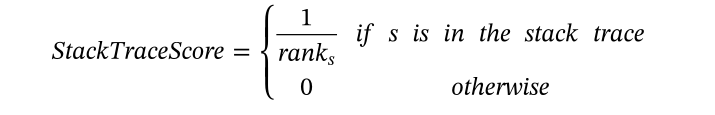

In [30]:
def stack_trace_component(report_strings, src_strings):
    st_matrix = np.zeros((len(report_strings), len(src_strings)), dtype=np.float32)
    idx_i = 0
    idx_j = 0
    for i, bug in report_strings.items():
        for j, src in src_strings.items():
            if j in bug.stack_traces_remove:
                st_matrix[idx_i][idx_j] = 1 / (bug.strack_traces.index[j] + 1)
            idx_j += 1
        idx_i += 1
        idx_j = 0
    return st_matrix

st_matrix = bug_fixing_frequency(bug_to_src_map, report_strings, src_strings)
print(st_matrix)
print("Stack trace matrix shape:", fix_matrix.shape)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Stack trace matrix shape: (6495, 6165)


# 6. Class name similarity
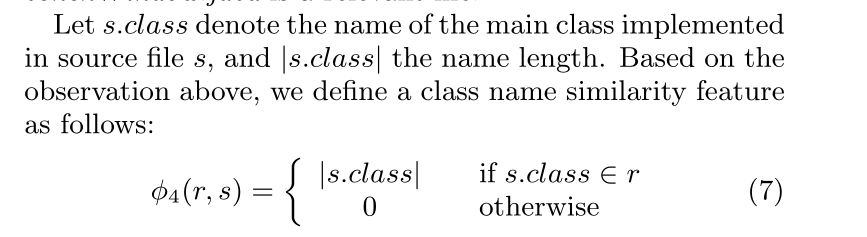

In [31]:
def class_name_similarity(report_strings, src_strings):
    cn_matrix = np.zeros((len(report_strings), len(src_strings)), dtype=np.float32)
    idx_i = 0
    idx_j = 0
    for i, bug in report_strings.items():
        for j, src in src_strings.items():
            if len(src.class_names['stemmed']) != 0:
                if src.class_names['stemmed'][0] in bug.summary['stemmed']:
                    cn_matrix[idx_i][idx_j] = len(src.class_names['stemmed'][0])
            idx_j += 1
        idx_i += 1
        idx_j = 0
    return cn_matrix

cn_matrix = class_name_similarity(report_strings, src_strings)
print(cn_matrix)
print("matrix shape:", cn_matrix.shape)


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
matrix shape: (6495, 6165)


In [32]:
rows, cols = np.where(cn_matrix != 0)
print(rows, cols)


[   0    0    0 ... 6494 6494 6494] [ 528 3005 5273 ... 4198 5273 5873]


# Build dataset

In [33]:
#lex_matrix
#sem_matrix
#sim_bug_matrix
#fix_matrix
#st_matrix

def build_dataset(lex_matrix, sem_matrix, sim_bug_matrix, fix_matrix, src_strings, report_strings):
    # X = []
    # y = []
    src_list = list(src_strings.items())
    bug_list = list(report_strings.items())   
    # split dataset into 10 folds base on bug_list, then save into csv
    step = len(bug_list) // 10
    for fold in range(10):
        start = fold * step
        end = (fold + 1) * step if fold < 9 else len(bug_list)
        X = []
        y = []
        for i in range(start, end):
            for j in range(len(src_strings)):
                features = [
                    bug_list[i][0],  # bug_id
                    lex_matrix[i][j],
                    sem_matrix[i][j],
                    sim_bug_matrix[i][j],
                    fix_matrix[i][j],
                    st_matrix[i][j],
                    cn_matrix[i][j]
                ]
                X.append(features)
                path_src, src = src_list[j]
                _, bug = bug_list[i]
                path_src = path_src.strip()
                if path_src in bug.fixed_files:
                    y.append(1)
                else:
                    y.append(0)
                # if bug == report_strings["11280"] and y[-1] == 1:
                #     print(path_src)
                # if path_src == 'weaver/src/org/aspectj/weaver/reflect/ReflectionBasedReferenceTypeDelegateFactory.java':
                #     print("ok")
                # elif path_src == ' weaver/src/org/aspectj/weaver/reflect/ReflectionBasedReferenceTypeDelegateFactory.java':
                #     print("not ok")
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int8)
        # save to csv
        df = pd.DataFrame(X, columns=['bug_id', 'lex_sim', 'sem_sim', 'sim_bug', 'fix_freq', 'st_trace', 'cn_matrix'])
        df['label'] = y
        csv_filename = f'fold_{fold+1}.csv'
        path = "Dataset/" + "K_folds_dataset/" + DATASET.name + "/" + csv_filename
        os.makedirs(os.path.dirname(path), exist_ok=True)
        df.to_csv(path, index=False)
        print(f"Saved fold {fold+1} to {path}")

In [34]:
build_dataset(lex_matrix, sem_matrix, sim_bug_matrix, fix_matrix, src_strings, report_strings)
# print("X: ", X)
# print("y: ", y)

Saved fold 1 to Dataset/K_folds_dataset/eclipse/fold_1.csv
Saved fold 2 to Dataset/K_folds_dataset/eclipse/fold_2.csv
Saved fold 3 to Dataset/K_folds_dataset/eclipse/fold_3.csv
Saved fold 4 to Dataset/K_folds_dataset/eclipse/fold_4.csv
Saved fold 5 to Dataset/K_folds_dataset/eclipse/fold_5.csv
Saved fold 6 to Dataset/K_folds_dataset/eclipse/fold_6.csv
Saved fold 7 to Dataset/K_folds_dataset/eclipse/fold_7.csv
Saved fold 8 to Dataset/K_folds_dataset/eclipse/fold_8.csv
Saved fold 9 to Dataset/K_folds_dataset/eclipse/fold_9.csv
Saved fold 10 to Dataset/K_folds_dataset/eclipse/fold_10.csv


In [35]:
# print(report_strings)
print(report_strings["10972"].fixed_files)
# print(bug_to_src_map['tests/src/org/aspectj/systemtest/ajc150/Ajc150Tests.java'])
# print(bug_to_src_map['weaver/src/org/aspectj/weaver/reflect/ReflectionBasedReferenceTypeDelegateFactory.java'])
# print(bug_to_src_map[' weaver/src/org/aspectj/weaver/reflect/ReflectionBasedReferenceTypeDelegateFactory.java'])


for key_src, val_src in src_strings.items():
    if key_src == ' weaver/src/org/aspectj/weaver/reflect/ReflectionBasedReferenceTypeDelegateFactory.java':
        print("1", val_src)
    if key_src == 'weaver/src/org/aspectj/weaver/reflect/ReflectionBasedReferenceTypeDelegateFactory.java':
        print("2", val_src)
    if key_src in report_strings["10972"].fixed_files:
        print("3", key_src)

KeyError: '10972'